In [1]:
import pandas as pd
import numpy as np
from scipy import stats

PATH_PIVOT = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\bigdata_viz\pivot_df.csv"
history_PIVOT = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\bigdata_viz\cafe_history.csv"

pivot = pd.read_csv(PATH_PIVOT, index_col='위치ID')
quarters     = list(pivot.columns)
quarter_nums = [int(q.replace('df_', '')) for q in quarters]

# 스타벅스 제외
cafe_history = pd.read_csv(history_PIVOT, index_col='위치ID')
cafe_history = cafe_history[cafe_history['brand'] != '스타벅스'].copy()
print(f'cafe_history (스벅 제외): {len(cafe_history)}행')
print(cafe_history['brand'].value_counts())

cafe_history (스벅 제외): 860526행
brand
일반카페      785578
이디야        23783
투썸플레이스     10433
빽다방         8403
컴포즈         7614
공차          5090
할리스         4178
탐앤탐스        3781
요거프레소       3553
파스쿠찌        2501
엔제리너스       1984
메가커피        1459
카페베네        1224
폴바셋          945
Name: count, dtype: int64


In [3]:
cafe_history['period_num'] = cafe_history['period'].str.replace('df_', '').astype(int)

spans = cafe_history.groupby(['위치ID', 'brand'])['period_num'].agg(
    입점분기='min', 퇴점분기='max', 생존분기수='count'
).reset_index()

spans['현재영업중'] = (spans['퇴점분기'] == 202512).astype(int)
spans['업종구분']   = np.where(spans['brand'] == '일반카페', '일반카페', '프랜차이즈')

print(f'전체 입점 이력: {len(spans)}개')
print(spans['업종구분'].value_counts())

전체 입점 이력: 43904개
업종구분
일반카페     40013
프랜차이즈     3891
Name: count, dtype: int64


## Step 2. 라벨링 (가설1과 동일 기준)
- 단기폐업 / 중기폐업 / 장수 / 제외
- 201512 입점 제외 (입점전 데이터 0분기 → 동어반복 차단)

In [4]:
def label(row):
    n, 현재 = row['생존분기수'], row['현재영업중']
    if 현재 == 1:
        return '장수' if n >= 32 else '제외'
    if n <= 8:  return '단기폐업'
    if n <= 32: return '중기폐업'
    return '장수'

spans['라벨'] = spans.apply(label, axis=1)

df2 = spans[
    (spans['라벨'] != '제외') &
    (spans['입점분기'] > 201512)
].copy()

print(f'분석 대상 (201512 제외, 현재영업중 단기 제외): {len(df2)}개')
print(df2.groupby('업종구분')['라벨'].value_counts())

분석 대상 (201512 제외, 현재영업중 단기 제외): 19255개
업종구분   라벨  
일반카페   단기폐업    7677
       중기폐업    7310
       장수      3040
프랜차이즈  중기폐업     528
       단기폐업     463
       장수       237
Name: count, dtype: int64


## Step 3. 입점전 교체횟수 / 공실횟수 / 생존분기수 계산

In [5]:
def calc_pre_entry(위치ID, 입점분기):
    if 위치ID not in pivot.index:
        return np.nan, np.nan, np.nan
    row   = pivot.loc[위치ID]
    pre_q = [q for q, n in zip(quarters, quarter_nums) if n < 입점분기]
    if not pre_q:
        return np.nan, np.nan, np.nan
    vals  = row[pre_q].values
    공실  = int(pd.isna(vals).sum())
    생존  = int(pd.notna(vals).sum())
    교체  = 0
    prev  = vals[0]
    for v in vals[1:]:
        if pd.isna(prev) != pd.isna(v):
            교체 += 1
        elif not pd.isna(prev) and not pd.isna(v) and prev != v:
            교체 += 1
        prev = v
    return 교체, 공실, 생존

print('입점전 변수 계산 중... (시간 소요)')
pre = df2.apply(lambda r: calc_pre_entry(r['위치ID'], r['입점분기']), axis=1)
df2['입점전_교체횟수']   = [x[0] for x in pre]
df2['입점전_공실횟수']   = [x[1] for x in pre]
df2['입점전_생존분기수'] = [x[2] for x in pre]
df2 = df2.dropna(subset=['입점전_교체횟수'])

print(f'계산 완료: {len(df2)}개')

입점전 변수 계산 중... (시간 소요)
계산 완료: 19243개


## Step 4. 전체 비교 — 일반카페 vs 프랜차이즈 (통제 전)

In [6]:
general = df2[df2['업종구분'] == '일반카페']['생존분기수']
brand   = df2[df2['업종구분'] == '프랜차이즈']['생존분기수']

print(f'일반카페   : n={len(general)}, 평균 생존 {general.mean():.2f}분기 ({general.mean()/4:.1f}년)')
print(f'프랜차이즈 : n={len(brand)}, 평균 생존 {brand.mean():.2f}분기 ({brand.mean()/4:.1f}년)')

t, p = stats.ttest_ind(general, brand, equal_var=False)
print(f'\nt-test: t={t:.3f}, p={"<0.001" if p < 0.001 else f"{p:.4f}"}')

일반카페   : n=18023, 평균 생존 15.81분기 (4.0년)
프랜차이즈 : n=1220, 평균 생존 16.87분기 (4.2년)

t-test: t=-2.904, p=0.0037


## Step 5. 입점전 교체횟수 구간별 비교 (히스토리 통제)
> **핵심 단계**: "같은 히스토리 조건에서" 일반카페 vs 프랜차이즈를 비교

In [7]:
df2['교체구간'] = pd.cut(df2['입점전_교체횟수'],
                        bins=[-1, 0, 2, 100],
                        labels=['없음(0)', '낮음(1-2)', '높음(3+)'])

for 구간 in ['없음(0)', '낮음(1-2)', '높음(3+)']:
    sub = df2[df2['교체구간'] == 구간]
    g = sub[sub['업종구분'] == '일반카페']['생존분기수']
    b = sub[sub['업종구분'] == '프랜차이즈']['생존분기수']

    print(f'\n[교체구간: {구간}]')
    print(f'  일반카페   : n={len(g)}, 평균 {g.mean():.2f}분기 ({g.mean()/4:.1f}년)')
    print(f'  프랜차이즈 : n={len(b)}, 평균 {b.mean():.2f}분기 ({b.mean()/4:.1f}년)')

    if len(g) > 1 and len(b) > 1:
        t, p = stats.ttest_ind(g, b, equal_var=False)
        sig = '<0.001' if p < 0.001 else f'{p:.4f}'
        print(f'  t-test: t={t:.3f}, p={sig}')


[교체구간: 없음(0)]
  일반카페   : n=11330, 평균 17.75분기 (4.4년)
  프랜차이즈 : n=681, 평균 20.90분기 (5.2년)
  t-test: t=-6.188, p=<0.001

[교체구간: 낮음(1-2)]
  일반카페   : n=4667, 평균 13.61분기 (3.4년)
  프랜차이즈 : n=290, 평균 14.00분기 (3.5년)
  t-test: t=-0.627, p=0.5308

[교체구간: 높음(3+)]
  일반카페   : n=2026, 평균 10.03분기 (2.5년)
  프랜차이즈 : n=249, 평균 9.20분기 (2.3년)
  t-test: t=1.583, p=0.1141


## Step 6. 결론용 종합 테이블

In [8]:
summary = df2.groupby(['교체구간', '업종구분'])['생존분기수'].agg(
    평균='mean', 중앙값='median', n='count'
).round(2)
print(summary)

                  평균   중앙값      n
교체구간    업종구분                     
없음(0)   일반카페   17.75  13.0  11330
        프랜차이즈  20.90  20.0    681
낮음(1-2) 일반카페   13.61   9.0   4667
        프랜차이즈  14.00  11.0    290
높음(3+)  일반카페   10.03   7.0   2026
        프랜차이즈   9.20   7.0    249


C:\Users\seohg\AppData\Local\Temp\ipykernel_40704\4273972145.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df2.groupby(['교체구간', '업종구분'])['생존분기수'].agg(


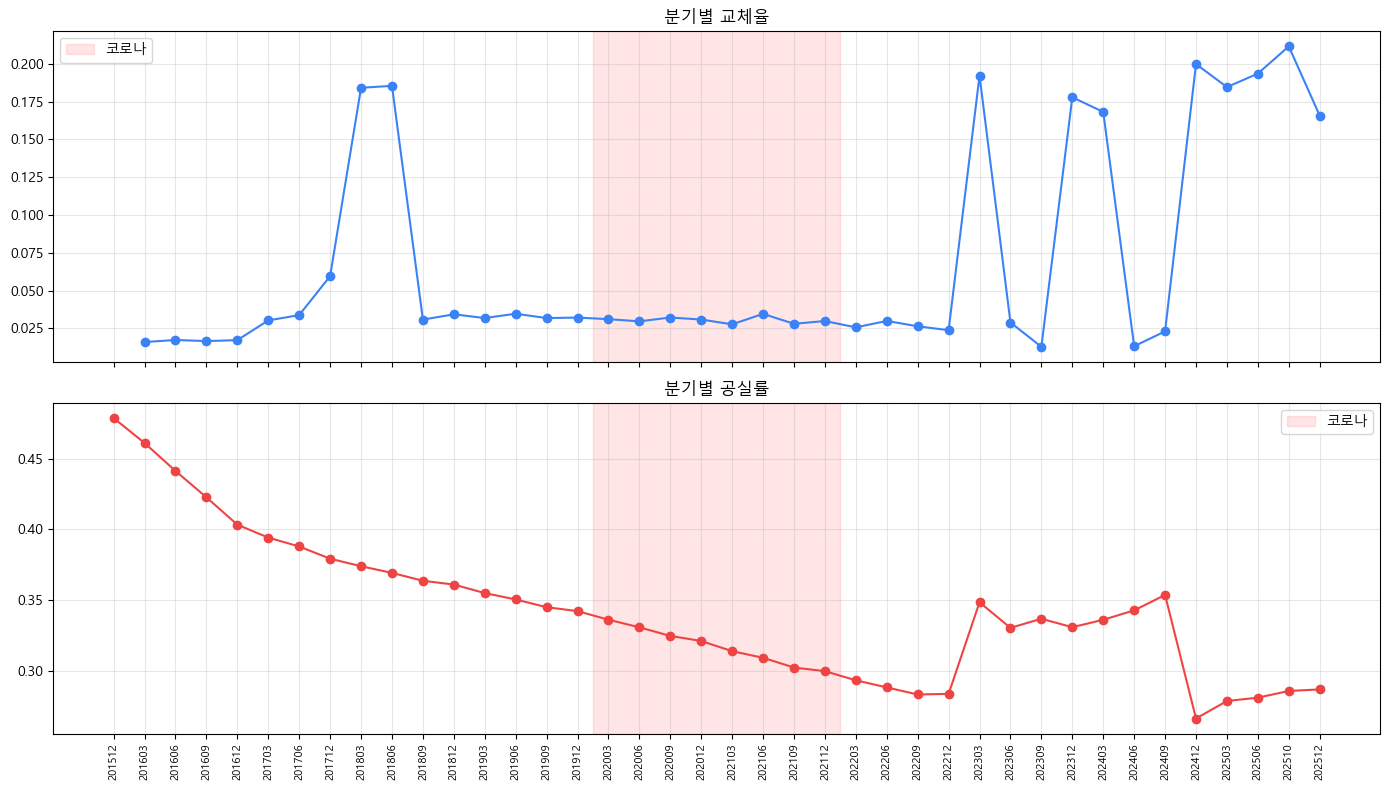

전체 교체율 0.0686 vs 코로나 0.0305
전체 공실률 0.3424 vs 코로나 0.3174


In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

quarters = list(pivot.columns)
quarter_nums = [int(q.replace('df_', '')) for q in quarters]
n_total = len(pivot)

records = []
for i in range(len(quarters)):
    curr_col = pivot[quarters[i]]
    공실률 = curr_col.isna().sum() / n_total

    if i == 0:
        교체율 = np.nan
    else:
        prev_col = pivot[quarters[i-1]]
        both_active = prev_col.notna() & curr_col.notna()
        교체 = (prev_col != curr_col) & both_active
        교체율 = 교체.sum() / both_active.sum()

    records.append({'quarter': quarter_nums[i], '공실률': 공실률, '교체율': 교체율})

trend = pd.DataFrame(records)

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
x = range(len(trend))

axes[0].plot(x, trend['교체율'], marker='o', color='#3B82F6')
axes[0].set_title('분기별 교체율')
axes[0].grid(alpha=0.3)

axes[1].plot(x, trend['공실률'], marker='o', color='#EF4444')
axes[1].set_title('분기별 공실률')
axes[1].set_xticks(x)
axes[1].set_xticklabels(trend['quarter'], rotation=90, fontsize=8)
axes[1].grid(alpha=0.3)

for ax in axes:
    covid_idx = [i for i, q in enumerate(trend['quarter']) if 202003 <= q <= 202112]
    ax.axvspan(min(covid_idx)-0.5, max(covid_idx)+0.5, color='red', alpha=0.1, label='코로나')
    ax.legend()

plt.tight_layout()
plt.show()

# 코로나 vs 전체 비교
전체_교체율 = trend['교체율'].mean()
전체_공실률 = trend['공실률'].mean()
covid = trend[(trend['quarter'] >= 202003) & (trend['quarter'] <= 202112)]
print(f"전체 교체율 {전체_교체율:.4f} vs 코로나 {covid['교체율'].mean():.4f}")
print(f"전체 공실률 {전체_공실률:.4f} vs 코로나 {covid['공실률'].mean():.4f}")

1. 그룹별 상관관계 (입점전 변수 vs 생존분기수)

[입점전_교체횟수]
  일반카페    : r=-0.221, p=<0.001, n=18023
  프랜차이즈   : r=-0.388, p=<0.001, n=1220
  → 두 상관계수 차이: z=6.231, p=<0.05 (차이 있음)

[입점전_공실횟수]
  일반카페    : r=-0.266, p=<0.001, n=18023
  프랜차이즈   : r=-0.256, p=<0.001, n=1220
  → 두 상관계수 차이: z=-0.348, p=0.728 (차이 없음 = 기울기 동일)

[입점전_생존분기수]
  일반카페    : r=-0.186, p=<0.001, n=18023
  프랜차이즈   : r=-0.324, p=<0.001, n=1220
  → 두 상관계수 차이: z=4.981, p=<0.05 (차이 있음)

2. 회귀분석 — 상호작용항(업종구분 × 입점전_교체횟수)
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            17.2435      0.130    132.977      0.000      16.989      17.498
입점전_교체횟수             -1.7258      0.076    -22.816      0.000      -1.874      -1.578
업종_dummy              2.3744      0.530      4.479      0.000       1.335       3.413
입점전_교체횟수:업종_dummy    -0.3718      0.221     -1.682      0.093      -0.805       0.062

해석:
- 입점전_교체횟수 

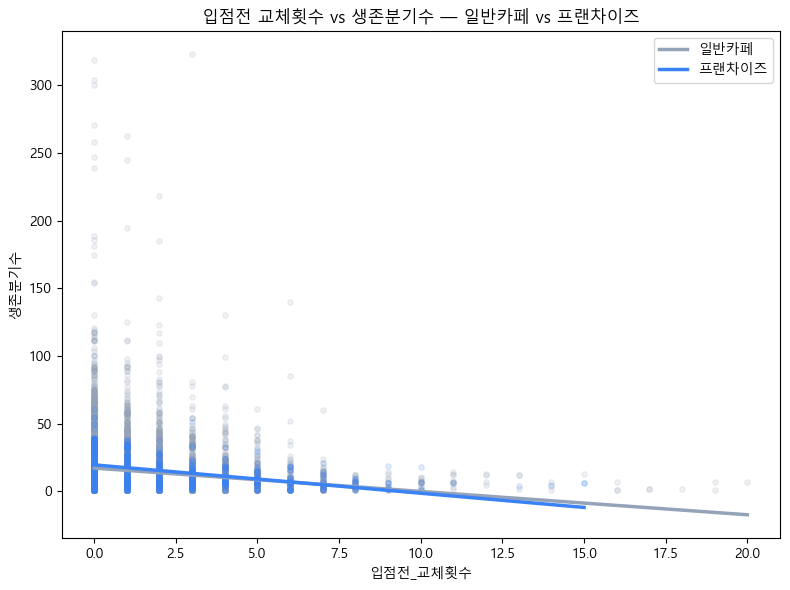

In [13]:
# ============================================================
# 일반카페 vs 프랜차이즈 — "관계의 강도" 비교
# (평균값이 아니라 상관관계/회귀 기울기 비교)
# ============================================================
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf

# df2: hypothesis2_data (위치ID, 입점전_교체횟수, 입점전_공실횟수,
#      입점전_생존분기수, 생존분기수, 업종구분 포함)

# ── 1. 그룹별 Spearman 상관관계 비교 ──────────────────────────
print("="*60)
print("1. 그룹별 상관관계 (입점전 변수 vs 생존분기수)")
print("="*60)

for col in ['입점전_교체횟수','입점전_공실횟수','입점전_생존분기수']:
    print(f"\n[{col}]")
    for 업종 in ['일반카페','프랜차이즈']:
        sub = df2[df2['업종구분']==업종]
        r, p = stats.spearmanr(sub[col], sub['생존분기수'])
        sig = '<0.001' if p < 0.001 else f'{p:.3f}'
        print(f"  {업종:8s}: r={r:.3f}, p={sig}, n={len(sub)}")

    # Fisher's z-test로 두 상관계수 차이 검정
    r1, _ = stats.spearmanr(df2[df2['업종구분']=='일반카페'][col],
                             df2[df2['업종구분']=='일반카페']['생존분기수'])
    r2, _ = stats.spearmanr(df2[df2['업종구분']=='프랜차이즈'][col],
                             df2[df2['업종구분']=='프랜차이즈']['생존분기수'])
    n1 = (df2['업종구분']=='일반카페').sum()
    n2 = (df2['업종구분']=='프랜차이즈').sum()

    z1, z2 = np.arctanh(r1), np.arctanh(r2)
    se = np.sqrt(1/(n1-3) + 1/(n2-3))
    z = (z1 - z2) / se
    p_diff = 2 * (1 - stats.norm.cdf(abs(z)))
    print(f"  → 두 상관계수 차이: z={z:.3f}, p={'<0.05' if p_diff<0.05 else f'{p_diff:.3f}'} "
          f"{'(차이 있음)' if p_diff<0.05 else '(차이 없음 = 기울기 동일)'}")


# ── 2. 회귀 상호작용항 검정 ───────────────────────────────────
print("\n" + "="*60)
print("2. 회귀분석 — 상호작용항(업종구분 × 입점전_교체횟수)")
print("="*60)

df2['업종_dummy'] = (df2['업종구분']=='프랜차이즈').astype(int)

model = smf.ols(
    '생존분기수 ~ 입점전_교체횟수 + 업종_dummy + 입점전_교체횟수:업종_dummy',
    data=df2
).fit()

print(model.summary().tables[1])

print("\n해석:")
print("- 입점전_교체횟수 계수      : 일반카페 기준 기울기 (위치효과)")
print("- 업종_dummy 계수           : 프랜차이즈의 절편 차이 (출발선 차이)")
print("- 상호작용항 계수 & p-value : 기울기 차이")
print("  → 상호작용항 p>0.05 이면 '기울기 동일' = 위치효과는 브랜드 무관하게 동일")


# ── 3. 시각화 — 회귀선 비교 ────────────────────────────────
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8,6))
for 업종, color in [('일반카페','#94A3B8'), ('프랜차이즈','#3B82F6')]:
    sub = df2[df2['업종구분']==업종]
    ax.scatter(sub['입점전_교체횟수'], sub['생존분기수'], alpha=0.15, color=color, s=15)

    # 회귀선
    z = np.polyfit(sub['입점전_교체횟수'], sub['생존분기수'], 1)
    x_line = np.linspace(0, sub['입점전_교체횟수'].max(), 50)
    ax.plot(x_line, np.poly1d(z)(x_line), color=color, linewidth=2.5, label=업종)

ax.set_xlabel('입점전_교체횟수')
ax.set_ylabel('생존분기수')
ax.set_title('입점전 교체횟수 vs 생존분기수 — 일반카페 vs 프랜차이즈')
ax.legend()
plt.tight_layout()
plt.savefig('hypothesis2_slope_compare.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df2.to_csv('hypothesis2_data.csv', index=False, encoding='utf-8-sig')
print('hypothesis2_data.csv 저장 완료')import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

quarters       = list(pivot.columns)
quarter_nums   = [int(q.replace('df_', '')) for q in quarters]
quarter_to_idx = {n: i for i, n in enumerate(quarter_nums)}

RADIUS_M = 500
EARTH_R  = 6371000
RADIUS_RAD = RADIUS_M / EARTH_R

print('준비 완료')

import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

quarters       = list(pivot.columns)
quarter_nums   = [int(q.replace('df_', '')) for q in quarters]
quarter_to_idx = {n: i for i, n in enumerate(quarter_nums)}

RADIUS_M = 500
EARTH_R  = 6371000

import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

quarters       = list(pivot.columns)
quarter_nums   = [int(q.replace('df_', '')) for q in quarters]
quarter_to_idx = {n: i for i, n in enumerate(quarter_nums)}

RADIUS_M = 500
EARTH_R  = 6371000
RADIUS_RAD = RADIUS_M / EARTH_R

print('준비 완료')
RADIUS_RAD = RADIUS_M / EARTH_R

print('준비 완료')

In [ ]:
cafe = cafe_history[cafe_history['brand'] != '스타벅스'].copy()
cafe['period_num'] = cafe['period'].str.replace('df_', '').astype(int)

spans = cafe.groupby(['위치ID', '상가업소번호']).agg(
    입점분기=('period_num', 'min'),
    퇴점분기=('period_num', 'max'),
    생존분기수=('period_num', 'count'),
    brand=('brand', 'first')
).reset_index()

spans['현재영업중'] = (spans['퇴점분기'] == 202512).astype(int)

def label(row):
    n, 현재 = row['생존분기수'], row['현재영업중']
    if 현재 == 1:
        return '장수' if n >= 32 else '제외'
    if n <= 8:  return '단기폐업'
    if n <= 32: return '중기폐업'
    return '장수'

spans['라벨'] = spans.apply(label, axis=1)

df = spans[(spans['라벨'] != '제외') & (spans['입점분기'] > 201512)].copy()
print(f'분석 대상: {len(df)}개')
print(df['brand'].value_counts())
print(df['라벨'].value_counts())

In [ ]:
def calc_pre_entry(위치ID, 입점분기):
    if 위치ID not in pivot.index:
        return np.nan, np.nan, np.nan
    row   = pivot.loc[위치ID]
    pre_q = [q for q, n in zip(quarters, quarter_nums) if n < 입점분기]
    if not pre_q:
        return np.nan, np.nan, np.nan
    vals  = row[pre_q].values
    공실  = int(pd.isna(vals).sum())
    생존  = int(pd.notna(vals).sum())
    교체  = 0
    prev  = vals[0]
    for v in vals[1:]:
        if pd.isna(prev) != pd.isna(v):
            교체 += 1
        elif not pd.isna(prev) and not pd.isna(v) and prev != v:
            교체 += 1
        prev = v
    return 교체, 공실, 생존

print('계산 중...')
pre = df.apply(lambda r: calc_pre_entry(r['위치ID'], r['입점분기']), axis=1)
df['입점전_교체횟수']   = [x[0] for x in pre]
df['입점전_공실횟수']   = [x[1] for x in pre]
df['입점전_생존분기수'] = [x[2] for x in pre]
df = df.dropna(subset=['입점전_교체횟수'])
print(f'완료: {len(df)}개')

In [ ]:
df = df.merge(viz[['위치ID','층구분','지하철거리_m','건물내위치수',
                    '연면적','도로유형','위도','경도']], on='위치ID', how='left')

loc_coords_bak = cafe.dropna(subset=['위도','경도']).drop_duplicates('위치ID')\
                     .set_index('위치ID')[['위도','경도']]
df['위도'] = df['위도'].fillna(df['위치ID'].map(loc_coords_bak['위도']))
df['경도'] = df['경도'].fillna(df['위치ID'].map(loc_coords_bak['경도']))

df['층구분'] = df['층구분'].fillna('층정보없음')
for col in ['지하철거리_m','건물내위치수','연면적']:
    df[col] = df[col].fillna(df[col].median())
df['도로유형'] = df['도로유형'].fillna(df['도로유형'].mode()[0])

print(df[['층구분','지하철거리_m','건물내위치수','연면적','도로유형','위도','경도']].isnull().sum())

In [ ]:
df = df.merge(result[['위치ID','TRDAR_CD','TRDAR_CD_N','TRDAR_SE_1',
                       '상권평균교체','상권평균공실',
                       '공실_상권대비','교체_상권대비']], on='위치ID', how='left')

for col in ['상권평균교체','상권평균공실','공실_상권대비','교체_상권대비']:
    df[col] = df[col].fillna(0)
df['TRDAR_SE_1'] = df['TRDAR_SE_1'].fillna('정보없음')

print(f'TRDAR_CD 결측: {df["TRDAR_CD"].isnull().sum()} / {len(df)}')

In [ ]:
def to_period(q):
    if q <= 201612: return '2015-2016'
    if q <= 201812: return '2017-2018'
    if q <= 202012: return '2019-2020'
    if q <= 202212: return '2021-2022'
    return '2023-2025'

thresholds = sangkwon_timeseries.groupby('period')[['평균교체','평균공실']].median()
sang_idx   = sangkwon_timeseries.set_index(['TRDAR_CD','period'])

def get_stage(trdar_cd, period):
    key = (trdar_cd, period)
    if pd.isna(trdar_cd) or key not in sang_idx.index:
        return '정보없음'
    교체, 공실 = sang_idx.loc[key, ['평균교체','평균공실']]
    th_교체, th_공실 = thresholds.loc[period]
    if 교체 < th_교체 and 공실 < th_공실: return '안정'
    if 교체 < th_교체 and 공실 >= th_공실: return '잠재'
    if 교체 >= th_교체 and 공실 < th_공실: return '활성'
    return '침체'

df['입점period'] = df['입점분기'].apply(to_period)
df['상권단계']   = df.apply(lambda r: get_stage(r['TRDAR_CD'], r['입점period']), axis=1)

print(df['상권단계'].value_counts())

In [ ]:
coord_df = cafe.dropna(subset=['위도','경도'])
trees = {}
for q in coord_df['period'].unique():
    sub = coord_df[coord_df['period'] == q]
    trees[q] = BallTree(np.radians(sub[['위도','경도']].values), metric='haversine')

print(f'{len(trees)}개 분기 BallTree 생성 완료')

In [ ]:
def add_competitor_density(target_df, q_col='입점분기'):
    target_df['경쟁자_수_입점시점'] = np.nan
    target_df['경쟁자_수_2년전']   = np.nan

    for q_num in target_df[q_col].unique():
        mask = (target_df[q_col] == q_num) & target_df['위도'].notna()
        if mask.sum() == 0:
            continue
        pts = np.radians(target_df.loc[mask, ['위도','경도']].values)

        q_key = f'df_{q_num}'
        if q_key in trees:
            target_df.loc[mask, '경쟁자_수_입점시점'] = \
                trees[q_key].query_radius(pts, r=RADIUS_RAD, count_only=True)

        idx = quarter_to_idx.get(q_num)
        if idx is not None and idx - 8 >= 0:
            q_key_past = quarters[idx - 8]
            if q_key_past in trees:
                target_df.loc[mask, '경쟁자_수_2년전'] = \
                    trees[q_key_past].query_radius(pts, r=RADIUS_RAD, count_only=True)

    target_df['경쟁자_수_입점시점'] = target_df['경쟁자_수_입점시점'].fillna(0)
    target_df['경쟁자_수_2년전']   = target_df['경쟁자_수_2년전'].fillna(0)

    cur, past = target_df['경쟁자_수_입점시점'], target_df['경쟁자_수_2년전']
    target_df['경쟁자_증가율'] = np.where(
        past == 0, np.where(cur > 0, 1.0, 0.0), (cur - past) / past
    )
    return target_df

df = add_competitor_density(df, q_col='입점분기')
print(df[['경쟁자_수_입점시점','경쟁자_수_2년전','경쟁자_증가율']].describe())

In [ ]:
feature_cols = [
    '입점전_교체횟수', '입점전_공실횟수', '입점전_생존분기수',
    '층구분', '지하철거리_m', '건물내위치수', '연면적', '도로유형',
    '상권단계', 'TRDAR_SE_1', '공실_상권대비', '교체_상권대비',
    '경쟁자_수_입점시점', '경쟁자_증가율',
    'brand'
]
cat_features = ['층구분', '도로유형', '상권단계', 'TRDAR_SE_1', 'brand']

MODEL_PARAMS = dict(iterations=150, depth=2, learning_rate=0.05,
                    l2_leaf_reg=15, verbose=0, random_seed=42)

print(f'피처 수: {len(feature_cols)}개')
print(f'brand 카테고리: {sorted(df["brand"].unique())}')

In [ ]:
models = {}
score_rows = []

for year in [3, 5, 8]:
    n_q = year * 4
    sub = df[df['입점분기'].apply(
        lambda x: x in quarter_to_idx and quarter_to_idx[x] + n_q < len(quarters))].copy()
    sub['y'] = ((sub['생존분기수'] > n_q) |
                ((sub['현재영업중'] == 1) & (sub['생존분기수'] >= n_q))).astype(int)

    X, y = sub[feature_cols].copy(), sub['y']
    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    aucs, accs, f1s, tr_accs, te_accs = [], [], [], [], []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        m = CatBoostClassifier(cat_features=cat_features, **MODEL_PARAMS)
        m.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_val, m.predict_proba(X_val)[:,1]))
        accs.append(accuracy_score(y_val, m.predict(X_val)))
        f1s.append(f1_score(y_val, m.predict(X_val)))
        tr_accs.append(m.score(X_tr, y_tr))
        te_accs.append(m.score(X_val, y_val))

    m_full = CatBoostClassifier(cat_features=cat_features, **MODEL_PARAMS)
    m_full.fit(X, y)
    models[year] = m_full

    gap = np.mean(tr_accs) - np.mean(te_accs)
    score_rows.append({
        '모델': f'{year}년차', '샘플': len(sub), '생존율': f'{y.mean():.1%}',
        'AUC': round(np.mean(aucs),3), 'Accuracy': round(np.mean(accs),3),
        'F1': round(np.mean(f1s),3),
        'Train': round(np.mean(tr_accs),3), 'Test': round(np.mean(te_accs),3),
        '과적합': '⚠️' if gap > 0.05 else '✅'
    })

print(pd.DataFrame(score_rows).set_index('모델').to_string())

In [ ]:
year = 5  # 대표로 5년차 확인
n_q = year*4
sub = df[df['입점분기'].apply(lambda x: x in quarter_to_idx and quarter_to_idx[x]+n_q < len(quarters))].copy()
sub['y'] = ((sub['생존분기수']>n_q) | ((sub['현재영업중']==1)&(sub['생존분기수']>=n_q))).astype(int)
X, y = sub[feature_cols].copy(), sub['y']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.zeros(len(sub))
for tr_idx, val_idx in skf.split(X, y):
    m = CatBoostClassifier(cat_features=cat_features, **MODEL_PARAMS)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_pred[val_idx] = m.predict_proba(X.iloc[val_idx])[:,1]
sub['oof_pred'] = oof_pred

print(f"{'brand':<10} {'n':>5} {'실제율':>7} {'예측평균':>8} {'AUC':>6}")
for brand, g in sub.groupby('brand'):
    if g['y'].nunique()==2 and len(g)>=10:
        auc = f"{roc_auc_score(g['y'], g['oof_pred']):.3f}"
    else:
        auc = 'N/A'
    print(f"{brand:<10} {len(g):>5} {g['y'].mean():>7.1%} {g['oof_pred'].mean():>8.1%} {auc:>6}")

In [ ]:
empty_ids = pivot[pivot['df_202512'].isna()].index.tolist()
empty_df = pd.DataFrame({'위치ID': empty_ids})
empty_df = empty_df.merge(viz, on='위치ID', how='left')
empty_df = empty_df.merge(result[['위치ID','TRDAR_CD','TRDAR_CD_N','상권평균교체','상권평균공실',
                                    '공실_상권대비','교체_상권대비']], on='위치ID', how='left')
empty_df = empty_df.dropna(subset=['위도','경도','시군구명'])
print(f'공실: {len(empty_df)}개')

In [ ]:
def calc_vacancy_history(위치ID):
    """가상입점분기 = 마지막 영업 분기 + 1, 그 이전 이력으로 변수 계산"""
    if 위치ID not in pivot.index:
        return np.nan, np.nan, np.nan, np.nan
    vals = pivot.loc[위치ID].values
    occupied_idx = [i for i, v in enumerate(vals) if pd.notna(v)]

    if not occupied_idx:
        return 0, 0, 0, quarter_nums[0]

    last_occ = max(occupied_idx)
    가상_idx = last_occ + 1
    가상입점분기 = quarter_nums[가상_idx] if 가상_idx < len(quarter_nums) else quarter_nums[-1]

    pre_q = quarters[:가상_idx]
    if not pre_q:
        return 0, 0, 0, 가상입점분기

    pre_vals = pivot.loc[위치ID][pre_q].values
    공실 = int(pd.isna(pre_vals).sum())
    생존 = int(pd.notna(pre_vals).sum())
    교체 = 0
    prev = pre_vals[0]
    for v in pre_vals[1:]:
        if pd.isna(prev) != pd.isna(v): 교체 += 1
        elif not pd.isna(prev) and not pd.isna(v) and prev != v: 교체 += 1
        prev = v
    return 교체, 공실, 생존, 가상입점분기

print('가상입점분기 기준 이력 계산 중...')
hist = empty_df['위치ID'].apply(calc_vacancy_history)
empty_df['입점전_교체횟수']   = [x[0] for x in hist]
empty_df['입점전_공실횟수']   = [x[1] for x in hist]
empty_df['입점전_생존분기수'] = [x[2] for x in hist]
empty_df['가상입점분기']      = [x[3] for x in hist]

print('\n=== 학습데이터 vs 공실(B) 분포 비교 ===')
for col in ['입점전_교체횟수','입점전_공실횟수','입점전_생존분기수']:
    print(f'{col}: 학습 {df[col].mean():.2f} / 공실 {empty_df[col].mean():.2f}')

In [ ]:
for col in ['층구분','도로유형','TRDAR_SE_1']:
    empty_df[col] = empty_df[col].fillna('정보없음')
for col in ['지하철거리_m','건물내위치수','연면적']:
    empty_df[col] = empty_df[col].fillna(empty_df[col].median())
for col in ['상권평균교체','상권평균공실','공실_상권대비','교체_상권대비']:
    empty_df[col] = empty_df[col].fillna(0)

empty_df['입점period'] = empty_df['가상입점분기'].apply(to_period)
empty_df['상권단계']   = empty_df.apply(
    lambda r: get_stage(r['TRDAR_CD'], r['입점period']), axis=1)

empty_df = add_competitor_density(empty_df, q_col='가상입점분기')

print(empty_df['상권단계'].value_counts())

In [ ]:
def predict_with_brand(target_df, brand_value):
    e = target_df.copy()
    e['brand'] = brand_value
    for year in [3, 5, 8]:
        e[f'생존확률_{year}년'] = models[year].predict_proba(e[feature_cols])[:,1]
    e['생존확률_5년'] = np.minimum(e['생존확률_5년'], e['생존확률_3년'])
    e['생존확률_8년'] = np.minimum(e['생존확률_8년'], e['생존확률_5년'])
    e['종합점수'] = (e['생존확률_3년']*0.3 + e['생존확률_5년']*0.4 + e['생존확률_8년']*0.3)
    return e

empty_general = predict_with_brand(empty_df, '일반카페')

non_mono = ((empty_general['생존확률_5년'] > empty_general['생존확률_3년']) |
             (empty_general['생존확률_8년'] > empty_general['생존확률_5년'])).mean()
print(f'비단조 비율: {non_mono:.1%}')
print(empty_general[['생존확률_3년','생존확률_5년','생존확률_8년','종합점수']].describe().round(3))

In [ ]:
def grade(s):
    if s >= 0.75: return 'A'
    if s >= 0.60: return 'B'
    if s >= 0.45: return 'C'
    return 'D'

empty_general['등급'] = empty_general['종합점수'].apply(grade)
print(empty_general['등급'].value_counts())

empty_general.to_csv('empty_scored_general.csv', index=False, encoding='utf-8-sig')
print('empty_scored_general.csv 저장 완료')

In [ ]:
FRANCHISE_BRANDS = [
    '투썸플레이스','이디야','빽다방','공차','할리스','파스쿠찌','카페베네',
    '엔제리너스','탐앤탐스','폴바셋','컴포즈','메가커피','요거프레소'
]

all_top100 = []
for brand in FRANCHISE_BRANDS:
    e = predict_with_brand(empty_df, brand)
    top100 = e.sort_values('종합점수', ascending=False).head(100).copy()
    top100['brand'] = brand
    all_top100.append(top100)
    print(f'{brand}: 최고점수 {top100["종합점수"].max():.3f}, 100위 {top100["종합점수"].min():.3f}')

brand_top100 = pd.concat(all_top100, ignore_index=True)
print(f'\n전체: {len(brand_top100)}행')

In [ ]:
cols = ['위치ID','brand','도로명주소','시군구명','행정동명','층구분',
        '지하철거리_m','연면적','TRDAR_SE_1','TRDAR_CD_N','상권단계',
        '입점전_교체횟수','입점전_공실횟수','입점전_생존분기수',
        '생존확률_3년','생존확률_5년','생존확률_8년','종합점수','위도','경도']
out = brand_top100[cols].copy()

for c in ['생존확률_3년','생존확률_5년','생존확률_8년','종합점수']:
    out[c] = (out[c]*100).round(1)
out['지하철거리_m'] = out['지하철거리_m'].round(0).astype(int)
out['연면적']      = out['연면적'].round(0).astype(int)

out.to_csv('brand_top100.csv', index=False, encoding='utf-8-sig')
with open('brand_top100.json','w',encoding='utf-8') as f:
    json.dump(out.to_dict(orient='records'), f, ensure_ascii=False)

print(f'brand_top100.csv / json 저장 완료: {len(out)}행')